ADF Price: Statistic=-2.05, p-value=0.264
ADF Log Return: Statistic=-8.89, p-value=0.000


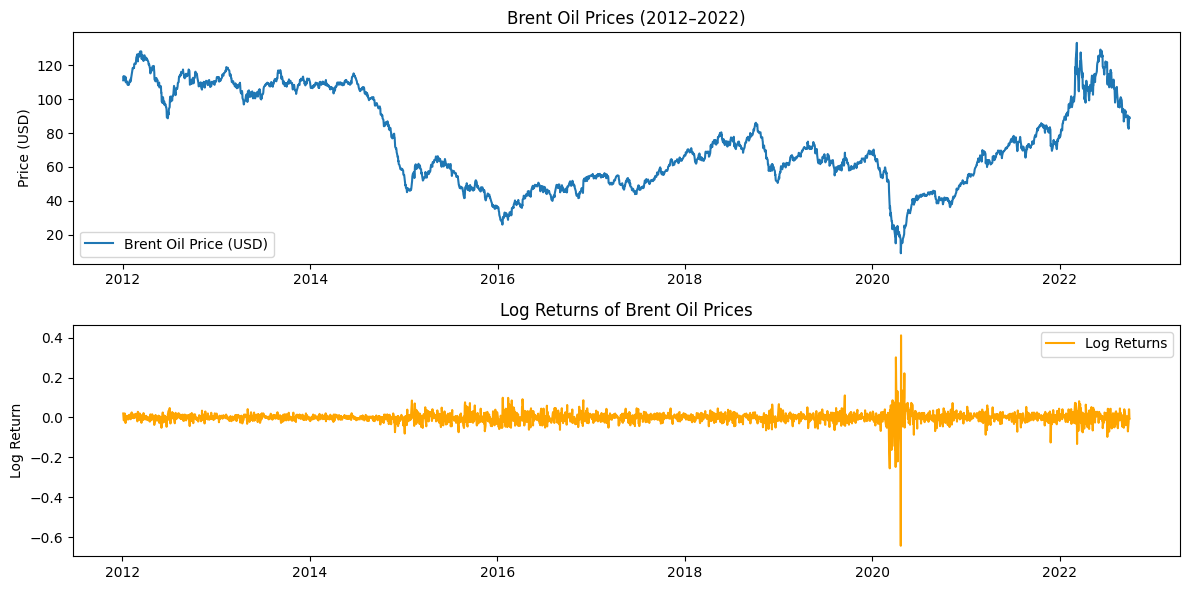

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Mixed date formats
dates = ["Apr 22, 2020", "2020-04-22", "22-Apr-20"]

# Convert with mixed format
df = pd.DataFrame({"dates": dates})
df["dates"] = pd.to_datetime(df["dates"], format="mixed", dayfirst=False)

# Load data (assumed CSV)
data = pd.read_csv('C:/Users/IE/Desktop/Week 10/raw/BrentOilPrices.csv')
data['Date'] = pd.to_datetime(data['Date'], format='mixed')
data = data[(data['Date'] >= '2012-01-01') & (data['Date'] <= '2022-09-30')]

# Compute log returns
data['Log_Price'] = np.log(data['Price'])
data['Log_Return'] = data['Log_Price'].diff()

# Plot prices and log returns
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(data['Date'], data['Price'], label='Brent Oil Price (USD)')
plt.title('Brent Oil Prices (2012–2022)')
plt.ylabel('Price (USD)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(data['Date'], data['Log_Return'], label='Log Returns', color='orange')
plt.title('Log Returns of Brent Oil Prices')
plt.ylabel('Log Return')
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/IE/Desktop/Week 10/test/eda_plots.png')

# Stationarity test
adf_price = adfuller(data['Price'].dropna())
adf_return = adfuller(data['Log_Return'].dropna())
print(f'ADF Price: Statistic={adf_price[0]:.2f}, p-value={adf_price[1]:.3f}')
print(f'ADF Log Return: Statistic={adf_return[0]:.2f}, p-value={adf_return[1]:.3f}')